In [1]:
import pandas as pd
import nltk
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy
from scipy.sparse import hstack
import numpy as np
import spacy
import re


In [2]:
#punkt è modello di tokenizzatore
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet = True)
#POS tokenizer per riconoscere grammaticalmente le parti dl discorso
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [ ]:
# Load + truncate to first quartile of sentences
df = pd.read_csv('../Dati/Raw/articles_clean.csv')

def truncate_to_25pct(text):
    if not isinstance(text, str): return ""
    s = nltk.sent_tokenize(text)
    return " ".join(s[:max(1, len(s)//4)])


In [ ]:
df['full_text'] = df['full_text'].apply(truncate_to_25pct)
df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [19]:
# Hard-threshold on the TRUNCATED text, at triplet level
df['word_count'] = df['full_text'].str.split().str.len()
invalid = df[df['word_count'] < 30]['topic_id'].unique()
df = df[~df['topic_id'].isin(invalid)].copy()

# keep only complete triplets (a dropped member kills the group)
counts = df['topic_id'].value_counts()
df = df[df['topic_id'].isin(counts[counts == 3].index)].copy()
df = df.drop(columns=['date'])  # all NaN

print(f"Topics: {df['topic_id'].nunique()} | Articles: {len(df)}")

Topics: 57 | Articles: 171


In [ ]:
# NER masking: nominal entities only (numbers/dates survive), single sentinel
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])
ENT = {"PERSON","NORP","ORG","GPE","LOC","FAC","EVENT","WORK_OF_ART","LAW","PRODUCT","LANGUAGE"}

def mask_entities(text):
    doc = nlp(text)
    for ent in reversed(doc.ents):
        if ent.label_ in ENT:
            text = text[:ent.start_char] + "ENT" + text[ent.end_char:]
    return text

In [ ]:
df['full_text'] = df['full_text'].apply(mask_entities)

In [ ]:
# Clean
def clean(text):
    text = re.sub(r'[^\w\s.,!?]', '', str(text))
    return re.sub(r'\s+', ' ', text).strip()


In [22]:
df['full_text'] = df['full_text'].apply(clean)

In [23]:
# POS tags
def pos_tags(text):
    return " ".join(t for _, t in nltk.pos_tag(nltk.word_tokenize(text)))


In [24]:
#Extract POS tags
df['pos_text'] = df['full_text'].apply(pos_tags)

In [25]:
# stylometric features (aligned to doc: char 1-3, pos 1-2, min_df 0.025)
# NOTE: fit here is for EDA/inference only. Inside CV, refit within a Pipeline to avoid leakage.
char_vec = TfidfVectorizer(analyzer='char', ngram_range=(1, 3), min_df=0.025, strip_accents='unicode')
pos_vec  = TfidfVectorizer(ngram_range=(1, 2), min_df=0.025)

char_X = char_vec.fit_transform(df['full_text'].astype(str))
pos_X  = pos_vec.fit_transform(df['pos_text'])
X = hstack([char_X, pos_X])
print(f"Features: {X.shape[1]}")

Features: 3830


In [ ]:
# Descriptive frequency (mean TF-IDF) — NOT discriminative importance
names = np.concatenate([char_vec.get_feature_names_out(), pos_vec.get_feature_names_out()])
prominence = pd.DataFrame({
    'feature': names,
    'prominence': np.asarray(X.mean(axis=0)).ravel()
}).sort_values('prominence', ascending=False)
print(prominence.head(20))

     feature  prominence
0               0.534845
3555      nn    0.401430
3580     nnp    0.351182
986        e    0.344310
3502      in    0.337016
2952       t    0.275170
3479      dt    0.253413
2053       n    0.231577
442        a    0.201174
1550       i    0.189463
2244       o    0.177524
3525      jj    0.173376
3606     nns    0.173104
2773       s    0.160145
2557       r    0.156458
3487   dt nn    0.121911
3560   nn in    0.119023
3717     vbd    0.114372
861        d    0.105300
1448       h    0.102743


In [27]:
######EDA############

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
#from wordcloud import WordCloud #Reminder per futuri grafici post risultati finali

binary_label
1    114
0     57
Name: count, dtype: int64
Majority baseline: 0.667
Complete triplets: 57


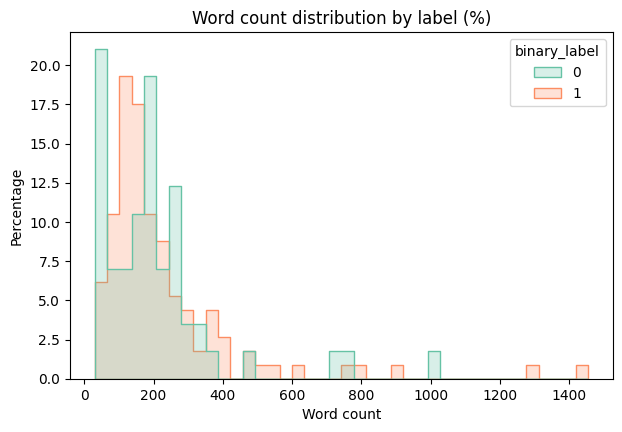

In [29]:
# Structural class imbalance (2:1 by triplet construction)
print(df['binary_label'].value_counts())
print(f"Majority baseline: {df['binary_label'].value_counts(normalize=True).max():.3f}")
print(f"Complete triplets: {(df['topic_id'].value_counts()==3).sum()}")

# word count now reflects the TRUNCATED text actually fed to the models
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x='word_count', hue='binary_label', element='step',
             bins=40, stat='percent', common_norm=False, palette="Set2", ax=ax)
ax.set(title="Word count distribution by label (%)", xlabel="Word count", ylabel="Percentage")
fig.savefig("../Risultati/word_count_distribution_by_label.png", dpi=300, bbox_inches="tight")
plt.show()

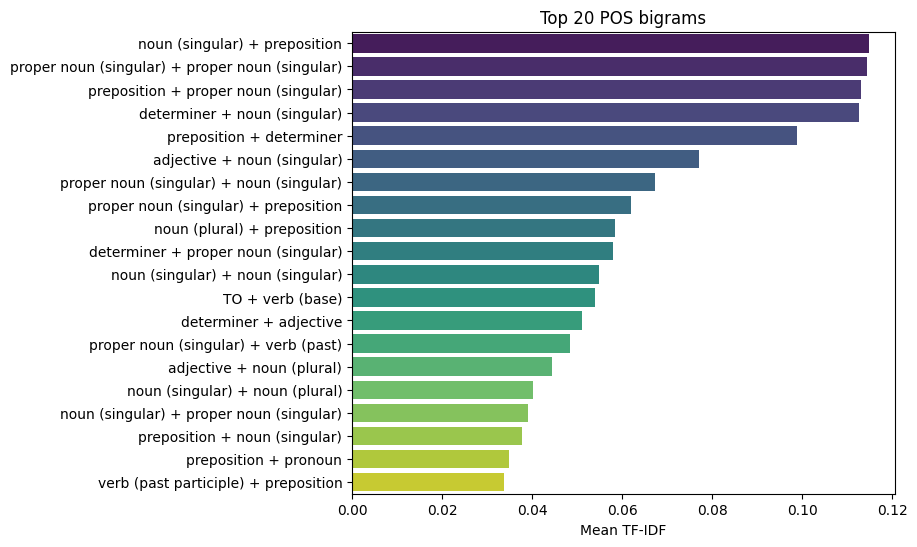

In [30]:
#Top POS n-grams (TF-IDF) — ONLY n > 1 (bigrams)

pos_only = feature_prominence[feature_prominence['feature'].isin(pos_names)].copy()

#n-grams with n > 1 --> bigrams
pos_only_bigrams = pos_only[pos_only['feature'].str.contains(r'\s')]

pos_prominence = pos_only_bigrams.sort_values(by='prominence', ascending=False).head(20)

#Now translate the acronysmsin the POS dictionary
pos_map = {
    "NN": "noun (singular)",
    "NNS": "noun (plural)",
    "NNP": "proper noun (singular)",
    "NNPS": "proper noun (plural)",
    "VB": "verb (base)",
    "VBD": "verb (past)",
    "VBG": "verb (gerund)",
    "VBN": "verb (past participle)",
    "VBP": "verb (non-3rd person singular present)",
    "VBZ": "verb (3rd person singular present)",
    "JJ": "adjective",
    "JJR": "adjective (comparative)",
    "JJS": "adjective (superlative)",
    "RB": "adverb",
    "RBR": "adverb (comparative)",
    "RBS": "adverb (superlative)",
    "IN": "preposition",
    "DT": "determiner",
    "PRP": "pronoun",
    "PRP$": "possessive pronoun",
    "CC": "coordinating conjunction",
    "CD": "cardinal number",
}

def decode_pos_bigram(bigram):
    tags = [t.strip().upper() for t in bigram.split()]
    return " + ".join([pos_map.get(t, t) for t in tags])

pos_prominence["readable_feature"] = pos_prominence["feature"].apply(decode_pos_bigram)

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(
    data=pos_prominence,
    x='prominence',
    y='readable_feature',
    hue='readable_feature',
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set(
    title="Top 20 POS bigrams",
    xlabel="Mean TF-IDF",
    ylabel=""
)


fig.savefig("../Risultati/TOP_20_POS_bigrams.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# save (vectorizers are inference artifacts, not for CV)
import joblib, json
df.to_csv("../Dati/Processed/dataset_processed_quantile1_sentences.csv", index=False)
joblib.dump(char_vec, "../Dati/Processed/artifacts/char_vectorizer.pkl")
joblib.dump(pos_vec,  "../Dati/Processed/artifacts/pos_vectorizer.pkl")
prominence.to_csv("../Dati/Processed/artifacts/feature_prominence.csv", index=False)
print("Saved.")

Saved.
